# Checkpoint 5 · Consumo de veículos

**Random Forest, XGBoost e LightGBM | FIAP · 2026**

Pergunta: **quanto um veículo percorre por galão de combustível, dadas suas características?**

Regressão supervisionada com a base Auto MPG. Cada exercício do modelo do professor é preservado abaixo, seguido da implementação e da interpretação dos resultados.

### Integrantes

| Nome             | RM     |
| ---------------- | ------ |
| Rafael Joda      | 561939 |
| Henrique Martins | 561876 |
| Luis Miguel      | 561232 |
| Diego Zandonadi  | 561488 |
| Davi Alves       | 566279 |

**Publicação:** links do GitHub e Streamlit pendentes; preencher no Exercício 7 e no README após publicar.

### Como executar

Execute todas as células em ordem. A primeira instala somente dependências ausentes; para reproduzir as versões do artefato entregue, use `pip install -r requirements.txt` no projeto completo.

No Colab, este notebook também baixa a base oficial caso a pasta `data` não exista.

São executadas duas estratégias de ajuste para cada um dos três algoritmos: **Grid Search com 8 combinações** e **Optuna com 20 tentativas**, sempre utilizando **validação cruzada com 5 folds**. Os tempos dependem do computador.

**Limite de uso:** dados históricos de veículos dos anos-modelo **1970–1982**. O aplicativo é uma demonstração acadêmica, não uma estimativa validada para veículos atuais.

In [1]:
import importlib.util, subprocess, sys
DEPENDENCIAS = {
    'numpy':'numpy', 'pandas':'pandas', 'sklearn':'scikit-learn',
    'matplotlib':'matplotlib', 'seaborn':'seaborn', 'joblib':'joblib',
    'xgboost':'xgboost', 'lightgbm':'lightgbm', 'optuna':'optuna',
}
faltantes = [pkg for mod,pkg in DEPENDENCIAS.items() if importlib.util.find_spec(mod) is None]
if faltantes:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *faltantes])

import os
for var in ['OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS']:
    os.environ[var] = '1'
import json, hashlib, platform, time, warnings
from pathlib import Path
from urllib.request import urlopen
from zipfile import ZipFile
from io import BytesIO
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, optuna
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import (train_test_split, KFold, cross_validate,
    cross_val_score, cross_val_predict, GridSearchCV, learning_curve)
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

SEED = 42
N_TRIALS = 20
BASE = Path.cwd()
for folder in ['data','results','artifacts']:
    (BASE / folder).mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', palette=['#167D9A','#E89239','#45556C'])
plt.rcParams.update({'figure.figsize':(9,5),'figure.dpi':110,
                     'axes.spines.top':False,'axes.spines.right':False})
optuna.logging.set_verbosity(optuna.logging.WARNING)
def texto(s): display(Markdown(s))
def salvar_fig(nome):
    plt.tight_layout()
    plt.savefig(BASE / 'results' / f'{nome}.png', dpi=160, bbox_inches='tight')
    plt.show()
    plt.close()
VERSOES = {p: metadata.version(p) for p in
           ['numpy','pandas','scikit-learn','xgboost','lightgbm','optuna','joblib','matplotlib','seaborn']}
print('Python:', platform.python_version())
display(pd.Series(VERSOES, name='versão').to_frame())


Python: 3.12.14


,versão
numpy,2.3.5
pandas,2.2.3
scikit-learn,1.8.0
xgboost,3.4.1
lightgbm,4.7.0
optuna,5.0.0
joblib,1.5.3
matplotlib,3.10.8
seaborn,0.13.2


<br>

---

<br>

### **Exercício 1 — Definição do problema e da base de dados — 1,0 ponto**

Escolha um problema real que possa ser tratado por **Random Forest**, **XGBoost** e **LightGBM**. O problema pode ser de classificação ou regressão.

1. **Contexto e problema — 0,25 ponto.** Descreva o contexto, a pergunta que será respondida e por que uma solução preditiva é adequada.
2. **Variável-alvo — 0,25 ponto.** Defina $y$, informe se o problema é de classificação ou regressão e explique o significado da previsão $\hat{y}$ no domínio escolhido.
3. **Base de dados — 0,25 ponto.** Informe a fonte, o método de obtenção, o número inicial de linhas e colunas, a unidade observacional e as principais variáveis disponíveis.
4. **Critério de sucesso — 0,25 ponto.** Defina a métrica principal que será usada para comparar os modelos e justifique a escolha. Métricas auxiliares podem ser utilizadas, mas deve existir uma métrica principal comum aos três algoritmos.

**Sugestões de apoio visual:** tabela com dicionário de dados, gráfico da distribuição da variável-alvo e, quando aplicável, gráfico da frequência das classes.

### Resposta · Problema e fonte
O objetivo é estimar **eficiência de combustível em ciclo urbano (MPG)** a partir de características
conhecidas do veículo. Uma previsão pode apoiar comparações entre veículos semelhantes ao conjunto histórico.
Como há exemplos com atributos e consumo medido, o problema é de regressão supervisionada.

- **Alvo `y`:** `mpg`, milhas por galão americano. `ŷ` é a eficiência estimada;
  maior MPG significa maior distância percorrida por unidade de combustível.
- **Fonte:** R. Quinlan (1993), *Auto MPG*, UCI Machine Learning Repository,
  DOI [10.24432/C5859H](https://doi.org/10.24432/C5859H),
  [página oficial](https://archive.ics.uci.edu/dataset/9/auto+mpg).
  A licença informada pela UCI é CC BY 4.0; a cópia distribuída mantém atribuição e dados originais.
- **Obtenção:** arquivo oficial `auto-mpg.data` do ZIP da UCI. São 398 linhas e 9 colunas:
  7 preditores, alvo e nome do carro. Unidade observacional: um registro de veículo/ano-modelo.
  A versão oficial já exclui 8 registros com alvo desconhecido presentes na versão original de 406 linhas.
- **Métrica principal:** MAE em MPG, a minimizar, por ser diretamente interpretável como
  magnitude média do erro. RMSE destaca erros grandes e R² compara a variância explicada com uma referência.
  Não estabelecemos uma precisão comercial arbitrária: a evidência será comparada com um preditor constante.

**Protocolo antecipado:** reservamos 20% antes da exploração. Isso antecipa a separação do Exercício 3
para impedir que o teste influencie as decisões dos exercícios anteriores. A exploração usa apenas treino.


In [2]:
DATA_URL = 'https://archive.ics.uci.edu/static/public/9/auto+mpg.zip'
data_path = BASE / 'data' / 'auto-mpg.data'
if not data_path.exists():
    with urlopen(DATA_URL, timeout=60) as response:
        with ZipFile(BytesIO(response.read())) as z:
            for nome in ['auto-mpg.data','auto-mpg.names']:
                (BASE / 'data' / nome).write_bytes(z.read(nome))
COLUNAS = ['mpg','cylinders','displacement','horsepower','weight',
           'acceleration','model_year','origin','car_name']
bruta = pd.read_csv(data_path, sep=r'\s+', names=COLUNAS,
                   na_values='?', quotechar='"')
SHA256_DADOS = hashlib.sha256(data_path.read_bytes()).hexdigest()
print('Dimensões iniciais:', bruta.shape)
print('SHA-256 da base:', SHA256_DADOS)
# Regra de integridade pré-definida: duplicata exata não pode cruzar treino/teste.
n_duplicatas = int(bruta.duplicated().sum())
dados = bruta.drop_duplicates().copy()
assert dados['mpg'].notna().all(), 'Alvos ausentes exigem revisar a versão da base.'
idx_treino, idx_teste = train_test_split(dados.index, test_size=0.20, random_state=SEED)
treino = dados.loc[idx_treino].copy()
# Não consultar as linhas reservadas até o Exercício 7.
print(f'Treino: {len(idx_treino)} | teste reservado: {len(idx_teste)} | duplicatas exatas: {n_duplicatas}')
dicionario = pd.DataFrame([
 ['mpg','Alvo','Eficiência em milhas por galão americano'],
 ['cylinders','Numérica discreta','Número de cilindros'],
 ['displacement','Numérica','Cilindrada em polegadas cúbicas'],
 ['horsepower','Numérica','Potência em horsepower; ? representa ausência'],
 ['weight','Numérica','Peso em libras'],
 ['acceleration','Numérica','Tempo de aceleração de 0 a 60 mph, em segundos'],
 ['model_year','Numérica discreta','Ano-modelo codificado: 70 = 1970'],
 ['origin','Categórica','1: EUA; 2: Europa; 3: Japão'],
 ['car_name','Identificação textual','Nome/modelo, excluído dos preditores'],
], columns=['Variável','Papel/tipo','Descrição'])
display(dicionario)
display(treino.head())
dicionario.to_csv(BASE/'results'/'dicionario.csv', index=False)


Dimensões iniciais: (398, 9)
SHA-256 da base: 48b830e11feee5572525f8f1691ddb9d38d3d7b7063edcd8fca672c2a5e17d8d
Treino: 318 | teste reservado: 80 | duplicatas exatas: 0


,Variável,Papel/tipo,Descrição
0,mpg,Alvo,Eficiência em milhas por galão americano
1,cylinders,Numérica discreta,Número de cilindros
2,displacement,Numérica,Cilindrada em polegadas cúbicas
3,horsepower,Numérica,Potência em horsepower; ? representa ausência
4,weight,Numérica,Peso em libras
5,acceleration,Numérica,"Tempo de aceleração de 0 a 60 mph, em segundos"
6,model_year,Numérica discreta,Ano-modelo codificado: 70 = 1970
7,origin,Categórica,1: EUA; 2: Europa; 3: Japão
8,car_name,Identificação textual,"Nome/modelo, excluído dos preditores"


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
18,27.0,4,97.0,88.0,2130.0,14.5,70,3,datsun pl510
376,37.0,4,91.0,68.0,2025.0,18.2,82,3,mazda glc custom l
248,36.1,4,91.0,60.0,1800.0,16.4,78,3,honda civic cvcc
177,23.0,4,115.0,95.0,2694.0,15.0,75,2,audi 100ls


<br>

---

<br>

### **Exercício 2 — Data wrangling e análise exploratória — 1,5 ponto**

Prepare a base para a etapa de modelagem. Toda transformação deve ser justificada e documentada.

1. **Diagnóstico de qualidade — 0,30 ponto.** Verifique tipos de dados, valores ausentes, duplicidades, categorias inconsistentes, valores impossíveis e outras anomalias relevantes.
2. **Tratamento dos dados — 0,40 ponto.** Execute o data wrangling necessário. Explique o que foi alterado, removido, imputado, convertido ou recodificado e por quê. Não remova observações ou variáveis apenas para melhorar métricas.
3. **Análise exploratória — 0,50 ponto.** Produza gráficos coerentes com o problema e interprete o que eles mostram sobre $\mathbf{X}$ e $\mathbf{y}$. A análise deve conter pelo menos três visualizações úteis ao desenvolvimento do modelo.
4. **Base final — 0,30 ponto.** Apresente as dimensões da base após o tratamento, verifique novamente ausências e duplicidades e registre quais decisões de preparação ainda precisarão ocorrer dentro do pipeline de modelagem.

**Sugestões de gráficos:** distribuição da variável-alvo; barras de valores ausentes; boxplots ou histogramas para variáveis numéricas; contagens para variáveis categóricas; matriz de correlação quando fizer sentido; relação entre variáveis importantes e o alvo.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Atenção:</strong> qualquer transformação que aprenda parâmetros dos dados, como imputação baseada em estatísticas da amostra ou codificação aprendida, deve ser ajustada sem acesso ao conjunto de teste. Quando aplicável, faça essas etapas dentro de um pipeline.
</div>

### Resposta · Tratamento sem vazamento
O parser converte `?` em `NaN` e respeita aspas nos nomes. Não removemos carros raros nem
extremos apenas para aumentar a pontuação. Valores positivos e domínios categóricos são verificações
de consistência, não filtros aprendidos a partir do alvo.

`horsepower` ausente será imputado pela **mediana calculada somente no treino de cada fold**.
`origin` terá one-hot encoding, também dentro do pipeline. Não é necessário padronizar a escala
para os três algoritmos baseados em árvores. Nomes terão espaços externos aparados apenas para identificação.
As ausências podem continuar na tabela bruta após a limpeza: serão resolvidas no pipeline.


Duplicatas no treino: 0


,tipo,ausentes,valores_distintos
mpg,float64,0,120
cylinders,int64,0,5
displacement,float64,0,78
horsepower,float64,5,89
weight,float64,0,286
acceleration,float64,0,90
model_year,int64,0,13
origin,int64,0,3
car_name,object,0,246


,Valores não positivos
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,318.00,318.00,318.00,313.00,318.00,318.00,318.0,318.00
mean,23.61,5.43,191.90,103.28,2969.02,15.64,76.1,1.59
std,7.93,1.68,102.98,37.36,840.62,2.76,3.6,0.81
min,9.00,3.00,68.00,46.00,1613.00,8.00,70.0,1.00
25%,17.50,4.00,98.50,75.00,2220.00,13.90,73.0,1.00
50%,22.45,4.00,148.50,92.00,2822.50,15.50,76.0,1.00
75%,29.72,6.00,259.50,122.00,3597.25,17.30,79.0,2.00
max,46.60,8.00,455.00,225.00,5140.00,24.80,82.0,3.00


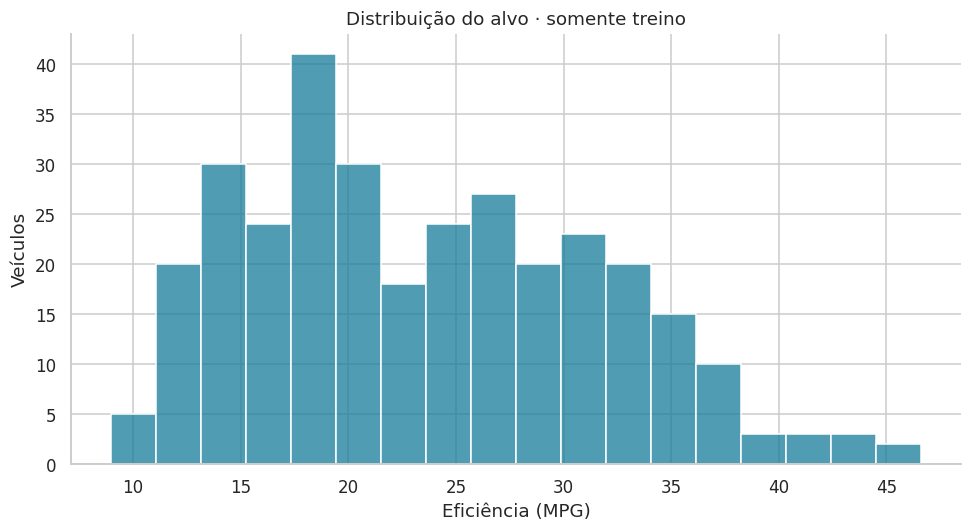

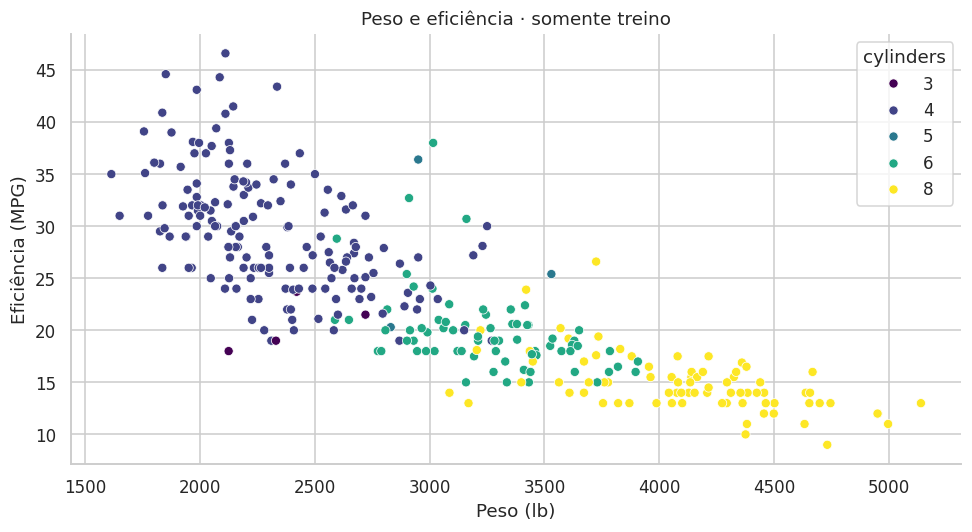

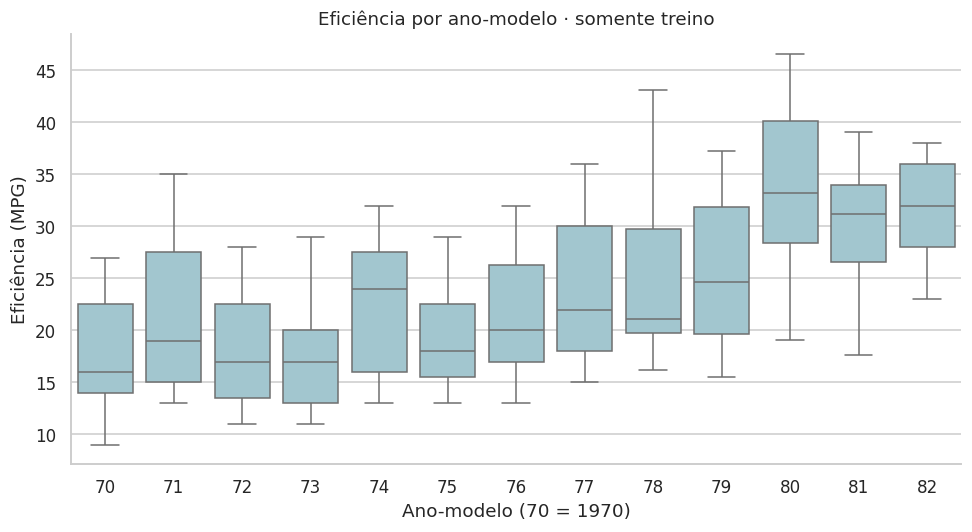

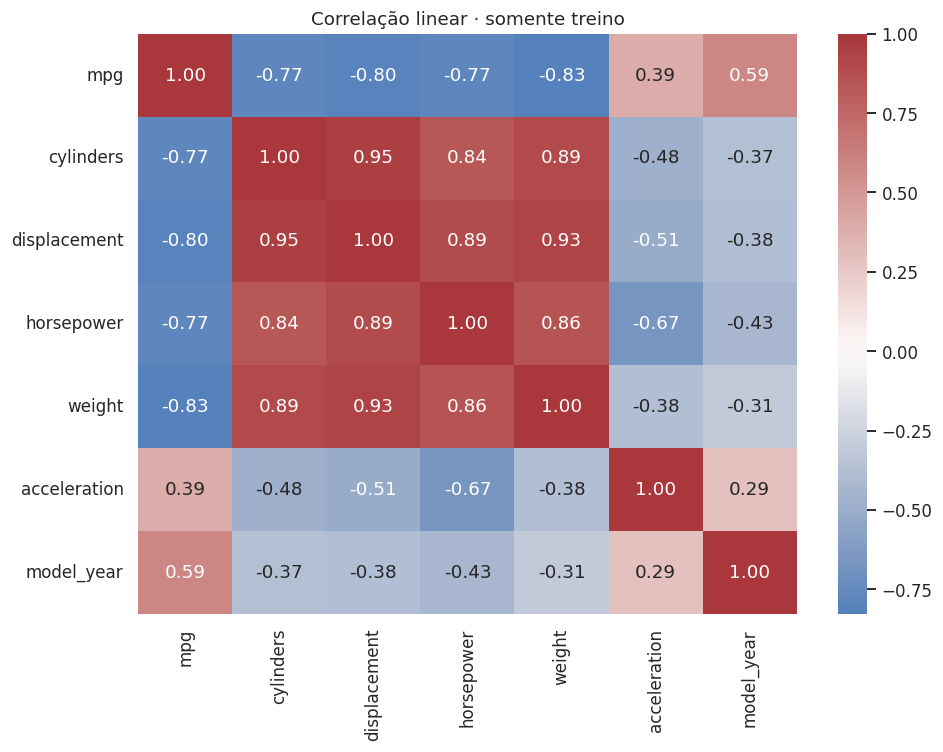

**Interpretação da exploração.** A mediana do alvo no treino é **22.45 MPG**,
com intervalo observado de 9.0 a 46.6 MPG.
A correlação peso–MPG é **-0.827**: neste conjunto, carros mais pesados tendem a percorrer
menos milhas por galão. Os boxplots mostram mediana de 16.00 MPG em 1970
e 32.00 MPG em 1982, além de dispersão dentro de cada ano.
Essas são associações observacionais, sem demonstração de causalidade.
A matriz permite identificar redundâncias entre peso, cilindrada, cilindros e potência;
mantemos essas variáveis porque são disponíveis na previsão e os modelos podem capturar interações.
Não eliminamos uma delas por um limiar arbitrário de correlação.

**Revisão após limpeza:** base com 398 linhas e 9 colunas;
treino com 318 linhas e 9 colunas, 0 duplicatas
e 5 ausências em potência a tratar dentro do pipeline.
Nenhum resultado do conjunto de teste foi inspecionado nesta exploração.

In [3]:
treino['car_name'] = treino['car_name'].str.strip()
diagnostico = pd.DataFrame({'tipo':treino.dtypes.astype(str),
    'ausentes':treino.isna().sum(), 'valores_distintos':treino.nunique()})
display(diagnostico)
print('Duplicatas no treino:', int(treino.duplicated().sum()))
positivas = ['mpg','cylinders','displacement','horsepower','weight','acceleration']
impossiveis = (treino[positivas] <= 0).sum()
display(impossiveis.rename('Valores não positivos').to_frame())
assert impossiveis.sum() == 0
assert set(treino.origin.unique()) <= {1,2,3}
assert treino.model_year.between(70,82).all()
assert set(treino.cylinders.unique()) <= {3,4,5,6,8}
display(treino.describe().round(2))

fig, ax = plt.subplots()
sns.histplot(treino.mpg, bins=18, ax=ax, color='#167D9A')
ax.set(xlabel='Eficiência (MPG)', ylabel='Veículos', title='Distribuição do alvo · somente treino')
salvar_fig('01_distribuicao_mpg')

fig, ax = plt.subplots()
sns.scatterplot(data=treino, x='weight', y='mpg', hue='cylinders', palette='viridis', ax=ax)
ax.set(xlabel='Peso (lb)', ylabel='Eficiência (MPG)', title='Peso e eficiência · somente treino')
salvar_fig('02_peso_mpg')

fig, ax = plt.subplots()
sns.boxplot(data=treino, x='model_year', y='mpg', color='#9ACAD7', ax=ax)
ax.set(xlabel='Ano-modelo (70 = 1970)', ylabel='Eficiência (MPG)', title='Eficiência por ano-modelo · somente treino')
salvar_fig('03_ano_mpg')

numericas = ['mpg','cylinders','displacement','horsepower','weight','acceleration','model_year']
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(treino[numericas].corr(), annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
ax.set_title('Correlação linear · somente treino')
salvar_fig('04_correlacoes')

corr_peso = treino.weight.corr(treino.mpg)
medianas_ano = treino.groupby('model_year').mpg.median()
texto(f"""**Interpretação da exploração.** A mediana do alvo no treino é **{treino.mpg.median():.2f} MPG**,
com intervalo observado de {treino.mpg.min():.1f} a {treino.mpg.max():.1f} MPG.
A correlação peso–MPG é **{corr_peso:.3f}**: neste conjunto, carros mais pesados tendem a percorrer
menos milhas por galão. Os boxplots mostram mediana de {medianas_ano.loc[70]:.2f} MPG em 1970
e {medianas_ano.loc[82]:.2f} MPG em 1982, além de dispersão dentro de cada ano.
Essas são associações observacionais, sem demonstração de causalidade.
A matriz permite identificar redundâncias entre peso, cilindrada, cilindros e potência;
mantemos essas variáveis porque são disponíveis na previsão e os modelos podem capturar interações.
Não eliminamos uma delas por um limiar arbitrário de correlação.

**Revisão após limpeza:** base com {len(dados)} linhas e {dados.shape[1]} colunas;
treino com {len(treino)} linhas e {treino.shape[1]} colunas, {int(treino.duplicated().sum())} duplicatas
e {int(treino.horsepower.isna().sum())} ausências em potência a tratar dentro do pipeline.
Nenhum resultado do conjunto de teste foi inspecionado nesta exploração.""")
diagnostico.to_csv(BASE/'results'/'qualidade_treino.csv')


<br>

---

<br>

### **Exercício 3 — Escolha de variáveis e desenho experimental — 1,0 ponto**

Defina formalmente o conjunto de variáveis utilizado na modelagem e estabeleça o protocolo experimental antes de treinar os algoritmos.

1. **Escolha das variáveis — 0,35 ponto.** Defina $\mathbf{X}$ e $\mathbf{y}$. Liste variáveis removidas e justifique a exclusão. Identificadores, informações disponíveis apenas depois do evento previsto e variáveis que revelem diretamente o alvo devem ser analisados como possíveis fontes de **data leakage**.
2. **Separação treino–teste e validação cruzada — 0,35 ponto.** Construa $\mathcal{D}_{\mathrm{treino}}$ e $\mathcal{D}_{\mathrm{teste}}$ com uma proporção adequada e `random_state` fixo. Em classificação, utilize estratificação quando aplicável. Defina o esquema de validação cruzada que será usado dentro de $\mathcal{D}_{\mathrm{treino}}$.
3. **Métricas — 0,30 ponto.** Registre a métrica principal e as métricas auxiliares. Explique por que elas são adequadas ao problema e como serão interpretadas.

**Referência de decisão:** para classificação, considere o balanceamento das classes ao escolher entre acurácia, precision, recall, F1, ROC-AUC ou outras métricas pertinentes. Para regressão, considere métricas como MAE, RMSE e $R^2$. A escolha deve ser justificada e mantida de forma consistente ao comparar os modelos.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Regra experimental:</strong> os três algoritmos devem utilizar o mesmo conjunto de teste e, sempre que possível, os mesmos folds de validação cruzada e a mesma métrica principal. O conjunto de teste não pode participar do Grid Search, do Optuna ou da escolha do melhor modelo.
</div>

### Resposta · Variáveis e protocolo
`X` contém cilindros, cilindrada, potência, peso, aceleração, ano-modelo e origem.
`y = mpg`. Excluímos `car_name`: é um rótulo textual de alta cardinalidade, com grafias
inconsistentes, desnecessário ao objetivo. O próprio alvo nunca entra em `X`.
Mantemos o tempo de aceleração supondo que essa especificação esteja disponível no momento da previsão.

- Separação aleatória **80% treino / 20% teste**, `random_state=42`.
- **KFold com 5 folds**, embaralhamento e semente 42, materializados e reutilizados em todas as buscas.
- MAE é a métrica principal; RMSE e R² são auxiliares. `neg_mean_absolute_error` é apenas a convenção
  do scikit-learn: negamos o score para apresentar MAE positivo.
- O teste representa outros registros da mesma população histórica, não veículos de anos futuros.
  Uma aplicação prospectiva exigiria avaliação temporal e dados mais recentes.
- Imputação e codificação ficam dentro de `Pipeline`/`ColumnTransformer` em cada fold.
  `origin` não é ordinal; one-hot evita impor uma distância numérica entre regiões.

A escolha e o tuning reutilizam os folds de desenvolvimento, portanto os melhores resultados de CV
podem ser otimistas. A avaliação reservada é a confirmação independente; não é permitido voltar ao tuning após vê-la.


In [4]:
FEATURES = ['cylinders','displacement','horsepower','weight','acceleration','model_year','origin']
NUM = [c for c in FEATURES if c != 'origin']
X_treino, y_treino = treino[FEATURES].copy(), treino.mpg.copy()
assert 'mpg' not in FEATURES and 'car_name' not in FEATURES
assert set(idx_treino).isdisjoint(idx_teste)
FOLDS = list(KFold(n_splits=5, shuffle=True, random_state=SEED).split(X_treino, y_treino))
PREPARADOR = ColumnTransformer([
    ('numericas', SimpleImputer(strategy='median'), NUM),
    ('origem', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['origin'])
], verbose_feature_names_out=False).set_output(transform='pandas')
def pipeline(modelo):
    return Pipeline([('preparacao',clone(PREPARADOR)),('modelo',modelo)])
SCORING = {'mae':'neg_mean_absolute_error', 'rmse':'neg_root_mean_squared_error', 'r2':'r2'}
cv_constante = -cross_val_score(DummyRegressor(strategy='mean'), X_treino, y_treino,
                              cv=FOLDS, scoring=SCORING['mae'], n_jobs=1)
print(f'Referência constante (média de treino de cada fold): MAE CV {cv_constante.mean():.3f} MPG')
display(pd.DataFrame([{'fold':i+1,'treino':len(a),'validacao':len(b)} for i,(a,b) in enumerate(FOLDS)]))
_ = (BASE/'results'/'split.json').write_text(json.dumps({
    'seed':SEED,'train_indices':idx_treino.tolist(),'test_indices':idx_teste.tolist(),
    'cv_indices_relative_to_train':[{'train':a.tolist(),'validation':b.tolist()} for a,b in FOLDS]
}, indent=2))


Referência constante (média de treino de cada fold): MAE CV 6.702 MPG


,fold,treino,validacao
0,1,254,64
1,2,254,64
2,3,254,64
3,4,255,63
4,5,255,63


<br>

---

<br>

### **Exercício 4 — Implementação dos três modelos de referência — 1,5 ponto**

Implemente uma primeira versão comparável dos três algoritmos antes do tuning:

$$
M_{\mathrm{RF}},
\qquad
M_{\mathrm{XGB}},
\qquad
M_{\mathrm{LGBM}}.
$$

Utilize as classes de classificação ou regressão correspondentes ao problema escolhido.

1. **Random Forest — 0,30 ponto.** Treine um modelo de referência e registre os hiperparâmetros utilizados.
2. **XGBoost — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
3. **LightGBM — 0,30 ponto.** Treine um modelo de referência sob o mesmo protocolo experimental.
4. **Comparação inicial — 0,60 ponto.** Construa uma tabela única contendo, no mínimo, modelo, métrica no treino, média da validação cruzada, desvio-padrão da validação cruzada e tempo de treinamento. Interprete as diferenças observadas e identifique sinais iniciais de overfitting ou underfitting.

O objetivo desta etapa é criar um **baseline comparável**, não encontrar ainda o melhor conjunto de hiperparâmetros.

**Sugestões de gráficos:** barras com a média e dispersão dos scores de validação cruzada; comparação entre score de treino e score médio de validação; tempo de treinamento por modelo.

### Resposta · Modelos de referência
As configurações abaixo são versões iniciais explícitas, sem usar o teste para defini-las.
Usamos uma thread por modelo e por CV para evitar paralelismo aninhado e facilitar a reprodução dos tempos.
O `min_child_samples=10` do LightGBM é uma escolha inicial compatível com a base pequena.
Não usamos early stopping dependente de um conjunto externo: a comparação usa os mesmos folds.

A coluna MAE de treino é a média dos scores nos subconjuntos de treino dos folds;
a comparação treino–validação usa, portanto, modelos treinados sobre as mesmas partições.
Reportamos tempo total da CV e média do tempo de ajuste por fold separadamente.


Baseline concluído: Random Forest
Baseline concluído: XGBoost
Baseline concluído: LightGBM


,modelo,estrategia,mae_treino,mae_cv,dp_mae_cv,rmse_cv,r2_cv,gap_mae,tempo_ajuste_fold_s,tempo_cv_total_s,tempo_busca_s
0,Random Forest,Baseline,0.7703,2.0325,0.1065,2.9796,0.8534,1.2623,0.1133,0.6659,0.0
1,XGBoost,Baseline,0.9381,1.9587,0.0899,2.7990,0.8705,1.0206,0.0174,0.1344,0.0
2,LightGBM,Baseline,0.5891,1.9580,0.2737,2.8418,0.8664,1.3689,0.0166,0.1315,0.0


,Random Forest,XGBoost,LightGBM
base_score,NaN,None,NaN
booster,NaN,None,NaN
boosting_type,NaN,NaN,gbdt
bootstrap,True,NaN,NaN
callbacks,NaN,None,NaN
...,...,...,...
tree_method,NaN,hist,NaN
validate_parameters,NaN,None,NaN
verbose,0,NaN,NaN
verbosity,NaN,None,-1


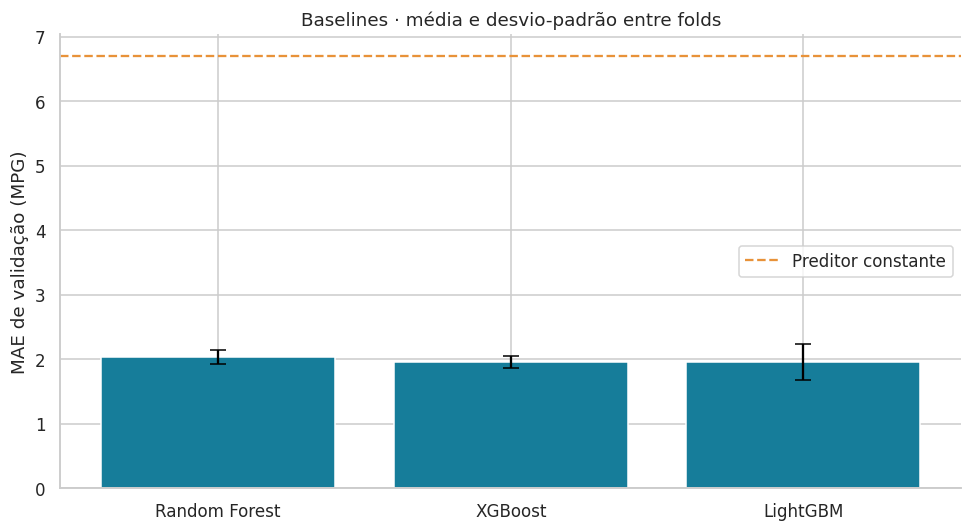

O menor MAE inicial é do **LightGBM: 1.958 MPG**.
A referência constante obteve 6.702 MPG.
O maior gap treino–validação é do LightGBM (1.369 MPG),
um sinal de possível sobreajuste. O ranking inicial não define o vencedor:
a dispersão entre folds e o tuning ainda precisam ser analisados.

In [5]:
BASELINES = {
    'Random Forest': RandomForestRegressor(n_estimators=120, random_state=SEED, n_jobs=1),
    'XGBoost': XGBRegressor(n_estimators=120, max_depth=3, learning_rate=0.10,
        objective='reg:squarederror', tree_method='hist', random_state=SEED, n_jobs=1),
    'LightGBM': LGBMRegressor(n_estimators=120, num_leaves=15, learning_rate=0.10,
        min_child_samples=10, verbosity=-1, random_state=SEED, n_jobs=1,
        deterministic=True, force_col_wise=True),
}
configuracoes, linhas = {}, []
def avaliar_config(nome, estrategia, estimador, tempo_busca=0.0):
    inicio = time.perf_counter()
    scores = cross_validate(estimador, X_treino, y_treino, cv=FOLDS, scoring=SCORING,
                            return_train_score=True, n_jobs=1, error_score='raise')
    mae_treino, mae_cv = -scores['train_mae'], -scores['test_mae']
    linha = {'modelo':nome, 'estrategia':estrategia,
        'mae_treino':float(mae_treino.mean()), 'mae_cv':float(mae_cv.mean()),
        'dp_mae_cv':float(mae_cv.std(ddof=1)),
        'rmse_cv':float(-scores['test_rmse'].mean()), 'r2_cv':float(scores['test_r2'].mean()),
        'gap_mae':float(mae_cv.mean()-mae_treino.mean()),
        'tempo_ajuste_fold_s':float(scores['fit_time'].mean()),
        'tempo_cv_total_s':time.perf_counter()-inicio, 'tempo_busca_s':tempo_busca}
    configuracoes[(nome,estrategia)] = clone(estimador)
    linhas.append(linha)
    pd.DataFrame({'mae_treino':mae_treino,'mae_validacao':mae_cv}).to_csv(
        BASE/'results'/f"folds_{nome.replace(' ','_')}_{estrategia}.csv",index=False)
    return linha
parametros_baseline = {}
for nome,modelo in BASELINES.items():
    parametros_baseline[nome] = modelo.get_params()
    avaliar_config(nome,'Baseline',pipeline(clone(modelo)))
    print('Baseline concluído:',nome,flush=True)
display(pd.DataFrame(linhas).round(4))
display(pd.DataFrame({k:pd.Series(v) for k,v in parametros_baseline.items()}))
(BASE/'results'/'parametros_baseline.json').write_text(json.dumps(parametros_baseline,indent=2,default=str))
baseline_df = pd.DataFrame(linhas)
fig, ax = plt.subplots()
ax.bar(baseline_df.modelo,baseline_df.mae_cv,yerr=baseline_df.dp_mae_cv,capsize=5,color='#167D9A')
ax.axhline(cv_constante.mean(),color='#E89239',linestyle='--',label='Preditor constante')
ax.set(ylabel='MAE de validação (MPG)',title='Baselines · média e desvio-padrão entre folds')
ax.legend()
salvar_fig('05_baselines')
melhor_base = baseline_df.sort_values('mae_cv').iloc[0]
maior_gap = baseline_df.sort_values('gap_mae',ascending=False).iloc[0]
texto(f"""O menor MAE inicial é do **{melhor_base.modelo}: {melhor_base.mae_cv:.3f} MPG**.
A referência constante obteve {cv_constante.mean():.3f} MPG.
O maior gap treino–validação é do {maior_gap.modelo} ({maior_gap.gap_mae:.3f} MPG),
um sinal de possível sobreajuste. O ranking inicial não define o vencedor:
a dispersão entre folds e o tuning ainda precisam ser analisados.""")


<br>

---

<br>

### **Exercício 5 — Tuning com Grid Search e Optuna — 2,0 pontos**

Ajuste os hiperparâmetros de **cada um dos três modelos** usando duas estratégias distintas: Grid Search e Optuna. Todo tuning deve ocorrer exclusivamente sobre $\mathcal{D}_{\mathrm{treino}}$ e utilizar o protocolo de validação definido no Exercício 3.

O problema geral pode ser representado como a busca por um conjunto de hiperparâmetros $\boldsymbol{\theta}$ que otimiza a métrica de validação cruzada:

$$
\boldsymbol{\theta}^{\star}
=
\operatorname*{arg\,opt}_{\boldsymbol{\theta}\in\Theta}
\frac{1}{K}
\sum_{k=1}^{K}
S_k(\boldsymbol{\theta}),
$$

em que $\operatorname*{arg\,opt}$ significa maximizar uma métrica de desempenho ou minimizar uma função de erro, conforme a métrica principal adotada.

1. **Grid Search — 0,75 ponto.** Para $M_{\mathrm{RF}}$, $M_{\mathrm{XGB}}$ e $M_{\mathrm{LGBM}}$, defina uma grade coerente de hiperparâmetros, execute a busca e registre os melhores parâmetros, o score médio de validação e o custo computacional. A grade deve explorar parâmetros que controlem complexidade, número de árvores e/ou taxa de aprendizado, conforme o algoritmo.
2. **Optuna — 1,00 ponto.** Para os três modelos, defina uma função objetivo baseada na mesma métrica principal e nos mesmos dados de validação. Documente o espaço de busca, o número de trials e o melhor conjunto de hiperparâmetros. Como referência, utilize pelo menos 20 trials por modelo ou justifique claramente uma quantidade menor por restrição computacional.
3. **Comparação das estratégias — 0,25 ponto.** Compare Grid Search e Optuna em qualidade da solução, custo computacional e comportamento da busca. Não escolha uma estratégia apenas porque produziu um número ligeiramente melhor; discuta estabilidade e complexidade.

**Sugestões de gráficos:** curva ou mapa de scores do `cv_results_` do Grid Search para hiperparâmetros relevantes; histórico de otimização do Optuna; importância dos hiperparâmetros no Optuna; tempo de busca por modelo e estratégia.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Controle de comparabilidade:</strong> mantenha a métrica principal, a preparação dos dados e o esquema de validação tão consistentes quanto possível entre os três modelos. Se houver diferença de pipeline necessária por causa de uma biblioteca ou tipo de variável, explique a diferença e por que ela não invalida a comparação.
</div>

### Resposta · Grid Search e Optuna para todos os algoritmos
Cada grade tem **8 combinações × 5 folds = 40 ajustes**, mais o refit do melhor.
Cada estudo Optuna executa **20 trials × 5 folds = 100 ajustes**, sem pruning e sem early stopping.
São três grades e três estudos. O sampler TPE usa semente 42 e execução sequencial.

**Grid:** Random Forest explora número de árvores, profundidade e tamanho mínimo de folha;
XGBoost explora árvores, profundidade e taxa de aprendizado; LightGBM explora árvores,
número de folhas e taxa de aprendizado. **Optuna** amplia os intervalos e inclui parâmetros
de regularização/amostragem. Os espaços aparecem integralmente no código abaixo.

Todos minimizam MAE sobre os mesmos cinco folds, sem acesso ao teste.
O orçamento de Optuna é maior e seu espaço é diferente: a comparação é operacional,
não um experimento controlado que demonstre superioridade universal de um método.


Grid Search Random Forest: MAE=2.0348; 4.9s
Grid Search XGBoost: MAE=1.9935; 1.0s
Grid Search LightGBM: MAE=1.9557; 0.8s
Optuna Random Forest: 20 trials; MAE=2.0127; 14.9s
Optuna XGBoost: 20 trials; MAE=1.9482; 3.1s
Optuna LightGBM: 20 trials; MAE=2.0108; 2.4s


,modelo,estrategia,mae_cv,tempo_s,candidatos,parametros
0,Random Forest,GridSearch,2.034845,4.944764,8,"{'modelo__max_depth': None, 'modelo__min_sampl..."
1,XGBoost,GridSearch,1.993484,1.032365,8,"{'modelo__learning_rate': 0.1, 'modelo__max_de..."
2,LightGBM,GridSearch,1.955714,0.848665,8,"{'modelo__learning_rate': 0.1, 'modelo__n_esti..."
3,Random Forest,Optuna,2.012724,14.897706,20,"{'n_estimators': 200, 'max_depth': None, 'min_..."
4,XGBoost,Optuna,1.948203,3.061193,20,"{'n_estimators': 200, 'max_depth': 4, 'learnin..."
5,LightGBM,Optuna,2.010780,2.357031,20,"{'n_estimators': 240, 'num_leaves': 20, 'learn..."


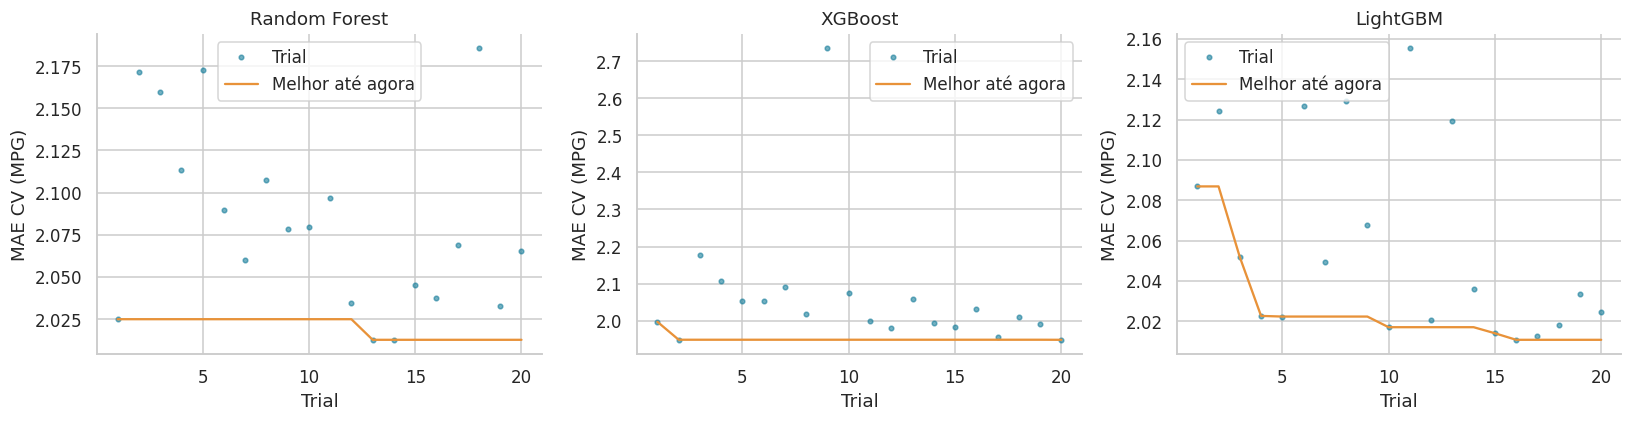

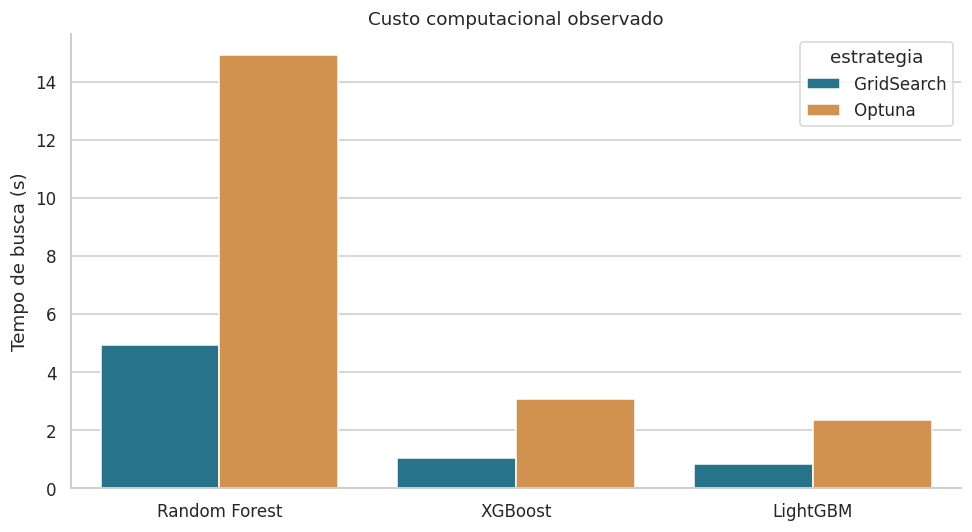

**Random Forest:** Grid = 2.035 MPG em 4.9s; Optuna = 2.013 MPG em 14.9s. Diferença Grid − Optuna: +0.022 MPG.

**XGBoost:** Grid = 1.993 MPG em 1.0s; Optuna = 1.948 MPG em 3.1s. Diferença Grid − Optuna: +0.045 MPG.

**LightGBM:** Grid = 1.956 MPG em 0.8s; Optuna = 2.011 MPG em 2.4s. Diferença Grid − Optuna: -0.055 MPG.

O histórico mostra a trajetória de cada estudo e eventuais períodos sem melhoria.
O desvio-padrão entre folds, comparado na próxima tabela, descreve sensibilidade à partição,
não a estabilidade entre diferentes execuções do otimizador. Não foram repetidas buscas com
múltiplas sementes; por isso não afirmamos significância estatística nem estabilidade entre sementes.

In [6]:
GRADES = {
 'Random Forest':{'modelo__n_estimators':[80,160], 'modelo__max_depth':[6,None],
                  'modelo__min_samples_leaf':[1,3]},
 'XGBoost':{'modelo__n_estimators':[80,160], 'modelo__max_depth':[2,4],
            'modelo__learning_rate':[0.03,0.10]},
 'LightGBM':{'modelo__n_estimators':[80,160], 'modelo__num_leaves':[7,15],
             'modelo__learning_rate':[0.03,0.10]},
}
grades, estudos, resumo_buscas = {}, {}, []
for nome,modelo in BASELINES.items():
    inicio = time.perf_counter()
    busca = GridSearchCV(pipeline(clone(modelo)), GRADES[nome],
        scoring=SCORING['mae'], cv=FOLDS, n_jobs=1, return_train_score=True, error_score='raise')
    busca.fit(X_treino,y_treino)
    duracao = time.perf_counter()-inicio
    grades[nome] = busca
    resultado = pd.DataFrame(busca.cv_results_)
    resultado.to_csv(BASE/'results'/f"grid_{nome.replace(' ','_')}.csv",index=False)
    resumo_buscas.append({'modelo':nome,'estrategia':'GridSearch','mae_cv':-busca.best_score_,
                         'tempo_s':duracao,'candidatos':len(resultado),'parametros':busca.best_params_})
    avaliar_config(nome,'GridSearch',busca.best_estimator_,duracao)
    print(f'Grid Search {nome}: MAE={-busca.best_score_:.4f}; {duracao:.1f}s',flush=True)

def sugerir(trial,nome):
    if nome == 'Random Forest':
        return {'n_estimators':trial.suggest_int('n_estimators',80,240,step=40),
                'max_depth':trial.suggest_categorical('max_depth',[None,4,6,10,16]),
                'min_samples_leaf':trial.suggest_int('min_samples_leaf',1,6),
                'max_features':trial.suggest_categorical('max_features',[0.7,1.0])}
    if nome == 'XGBoost':
        return {'n_estimators':trial.suggest_int('n_estimators',80,240,step=40),
                'max_depth':trial.suggest_int('max_depth',2,5),
                'learning_rate':trial.suggest_float('learning_rate',0.02,0.2,log=True),
                'min_child_weight':trial.suggest_float('min_child_weight',1,8),
                'subsample':trial.suggest_float('subsample',0.7,1.0),
                'colsample_bytree':trial.suggest_float('colsample_bytree',0.7,1.0),
                'reg_lambda':trial.suggest_float('reg_lambda',0.1,10,log=True)}
    return {'n_estimators':trial.suggest_int('n_estimators',80,240,step=40),
            'num_leaves':trial.suggest_int('num_leaves',5,25),
            'learning_rate':trial.suggest_float('learning_rate',0.02,0.2,log=True),
            'min_child_samples':trial.suggest_int('min_child_samples',5,25),
            'colsample_bytree':trial.suggest_float('colsample_bytree',0.7,1.0),
            'reg_lambda':trial.suggest_float('reg_lambda',0.01,10,log=True)}

for nome,modelo in BASELINES.items():
    def objetivo(trial):
        estimador = pipeline(clone(modelo).set_params(**sugerir(trial,nome)))
        erros = -cross_val_score(estimador,X_treino,y_treino,cv=FOLDS,
                                scoring=SCORING['mae'],n_jobs=1,error_score='raise')
        trial.set_user_attr('mae_por_fold',erros.tolist())
        trial.set_user_attr('dp_mae',float(erros.std(ddof=1)))
        return float(erros.mean())
    estudo = optuna.create_study(direction='minimize',sampler=optuna.samplers.TPESampler(seed=SEED))
    inicio = time.perf_counter()
    estudo.optimize(objetivo,n_trials=N_TRIALS,n_jobs=1,show_progress_bar=False)
    duracao = time.perf_counter()-inicio
    estudos[nome] = estudo
    estudo.trials_dataframe().to_csv(BASE/'results'/f"optuna_{nome.replace(' ','_')}.csv",index=False)
    resumo_buscas.append({'modelo':nome,'estrategia':'Optuna','mae_cv':estudo.best_value,
                         'tempo_s':duracao,'candidatos':len(estudo.trials),'parametros':estudo.best_params})
    avaliar_config(nome,'Optuna',pipeline(clone(modelo).set_params(**estudo.best_params)),duracao)
    print(f'Optuna {nome}: {len(estudo.trials)} trials; MAE={estudo.best_value:.4f}; {duracao:.1f}s',flush=True)

buscas_df = pd.DataFrame(resumo_buscas)
display(buscas_df)
buscas_df.to_csv(BASE/'results'/'comparacao_buscas.csv',index=False)
(BASE/'results'/'buscas.json').write_text(json.dumps(resumo_buscas,indent=2,default=str))
fig, axes = plt.subplots(1,3,figsize=(15,4))
for ax,(nome,estudo) in zip(axes,estudos.items()):
    valores = np.array([t.value for t in estudo.trials])
    ax.plot(np.arange(1,N_TRIALS+1),valores,'.',alpha=.6,label='Trial')
    ax.plot(np.arange(1,N_TRIALS+1),np.minimum.accumulate(valores),label='Melhor até agora')
    ax.set(title=nome,xlabel='Trial',ylabel='MAE CV (MPG)')
    ax.legend()
salvar_fig('06_historico_optuna')
fig,ax = plt.subplots()
sns.barplot(data=buscas_df,x='modelo',y='tempo_s',hue='estrategia',ax=ax)
ax.set(xlabel='',ylabel='Tempo de busca (s)',title='Custo computacional observado')
salvar_fig('07_tempo_buscas')
for nome in BASELINES:
    g = buscas_df[(buscas_df.modelo==nome)&(buscas_df.estrategia=='GridSearch')].iloc[0]
    o = buscas_df[(buscas_df.modelo==nome)&(buscas_df.estrategia=='Optuna')].iloc[0]
    texto(f'**{nome}:** Grid = {g.mae_cv:.3f} MPG em {g.tempo_s:.1f}s; '
          f'Optuna = {o.mae_cv:.3f} MPG em {o.tempo_s:.1f}s. '
          f'Diferença Grid − Optuna: {g.mae_cv-o.mae_cv:+.3f} MPG.')
texto("""O histórico mostra a trajetória de cada estudo e eventuais períodos sem melhoria.
O desvio-padrão entre folds, comparado na próxima tabela, descreve sensibilidade à partição,
não a estabilidade entre diferentes execuções do otimizador. Não foram repetidas buscas com
múltiplas sementes; por isso não afirmamos significância estatística nem estabilidade entre sementes.""")


<br>

---

<br>

### **Exercício 6 — Escolha do melhor modelo e análise de overfitting/underfitting — 1,5 ponto**

Com base apenas nos resultados de treinamento e validação cruzada, escolha a configuração que será promovida a modelo final. A escolha deve considerar desempenho, variabilidade entre folds, diferença entre treino e validação, custo e complexidade.

1. **Seleção do modelo — 0,50 ponto.** Construa uma tabela final com, no mínimo, as nove configurações principais: baseline, melhor Grid Search e melhor Optuna para cada um dos três algoritmos. Defina qual configuração será levada ao teste final e justifique a decisão.
2. **Overfitting e underfitting — 0,50 ponto.** Compare desempenho de treino e validação e produza uma **curva de aprendizado** para a configuração escolhida. Discuta se há evidências de overfitting, underfitting ou comportamento compatível com boa generalização.
3. **Interpretação do comportamento do modelo — 0,50 ponto.** Produza um gráfico de importância das variáveis para o modelo escolhido e pelo menos um gráfico de desempenho adequado ao tipo de problema:
   - **classificação:** matriz de confusão e, quando pertinente, curva ROC ou Precision–Recall;
   - **regressão:** valores observados versus previstos e/ou análise de resíduos.

Para uma métrica em que valores maiores representam melhor desempenho, um indício simples de sobreajuste pode ser observado pelo gap

$$
\Delta_{\uparrow}=S_{\mathrm{treino}}-S_{\mathrm{CV}}.
$$

Para uma função de erro em que valores menores são melhores, considere

$$
\Delta_{\downarrow}=L_{\mathrm{CV}}-L_{\mathrm{treino}}.
$$

Um gap elevado pode indicar sobreajuste, mas a conclusão deve considerar também a curva de aprendizado, a variabilidade dos folds e a escala da métrica.

### Resposta · Seleção feita antes do teste
Regra definida: escolher o **menor MAE médio de CV** entre as nove configurações; em empate numérico,
usar menor desvio-padrão e então menor tempo médio de ajuste por fold.
O ranking também exibe gap, custo e métricas auxiliares para discutir a escolha e suas limitações.

A curva de aprendizado usa apenas treino e os mesmos folds. O gráfico observado versus previsto
usa **previsões out-of-fold (OOF)**: cada registro é previsto por um ajuste que não o usou no treino.
Como a configuração foi escolhida usando esses folds, OOF aqui é diagnóstico de desenvolvimento,
não substitui uma avaliação independente.

Importância por permutação é calculada nas validações dos folds, em cada variável original.
Ela mede o aumento de MAE quando a informação é embaralhada; não estabelece causalidade.
Variáveis correlacionadas podem dividir importância e reduzir o efeito individual observado.


Configuração selecionada SEM consultar teste: ('XGBoost', 'Optuna')


,modelo,estrategia,mae_treino,mae_cv,dp_mae_cv,rmse_cv,r2_cv,gap_mae,tempo_ajuste_fold_s,tempo_cv_total_s,tempo_busca_s
0,XGBoost,Optuna,0.4952,1.9482,0.1523,2.8655,0.8649,1.4530,0.0316,0.2067,3.0612
1,LightGBM,GridSearch,0.7916,1.9557,0.2576,2.8473,0.8660,1.1641,0.0122,0.1047,0.8487
2,LightGBM,Baseline,0.5891,1.9580,0.2737,2.8418,0.8664,1.3689,0.0166,0.1315,0.0000
3,XGBoost,Baseline,0.9381,1.9587,0.0899,2.7990,0.8705,1.0206,0.0174,0.1344,0.0000
4,XGBoost,GridSearch,1.2433,1.9935,0.1135,2.7917,0.8724,0.7502,0.0153,0.1203,1.0324
5,LightGBM,Optuna,0.7526,2.0108,0.2301,2.9496,0.8571,1.2582,0.0294,0.2089,2.3570
6,Random Forest,Optuna,0.7628,2.0127,0.1042,2.9294,0.8579,1.2499,0.1597,0.9308,14.8977
7,Random Forest,Baseline,0.7703,2.0325,0.1065,2.9796,0.8534,1.2623,0.1133,0.6659,0.0000
8,Random Forest,GridSearch,0.7718,2.0348,0.1076,2.9751,0.8536,1.2630,0.1468,0.8504,4.9448


,parâmetro
objective,reg:squarederror
base_score,None
booster,None
callbacks,None
colsample_bylevel,None
colsample_bynode,None
colsample_bytree,0.995828
device,None
early_stopping_rounds,None
enable_categorical,True


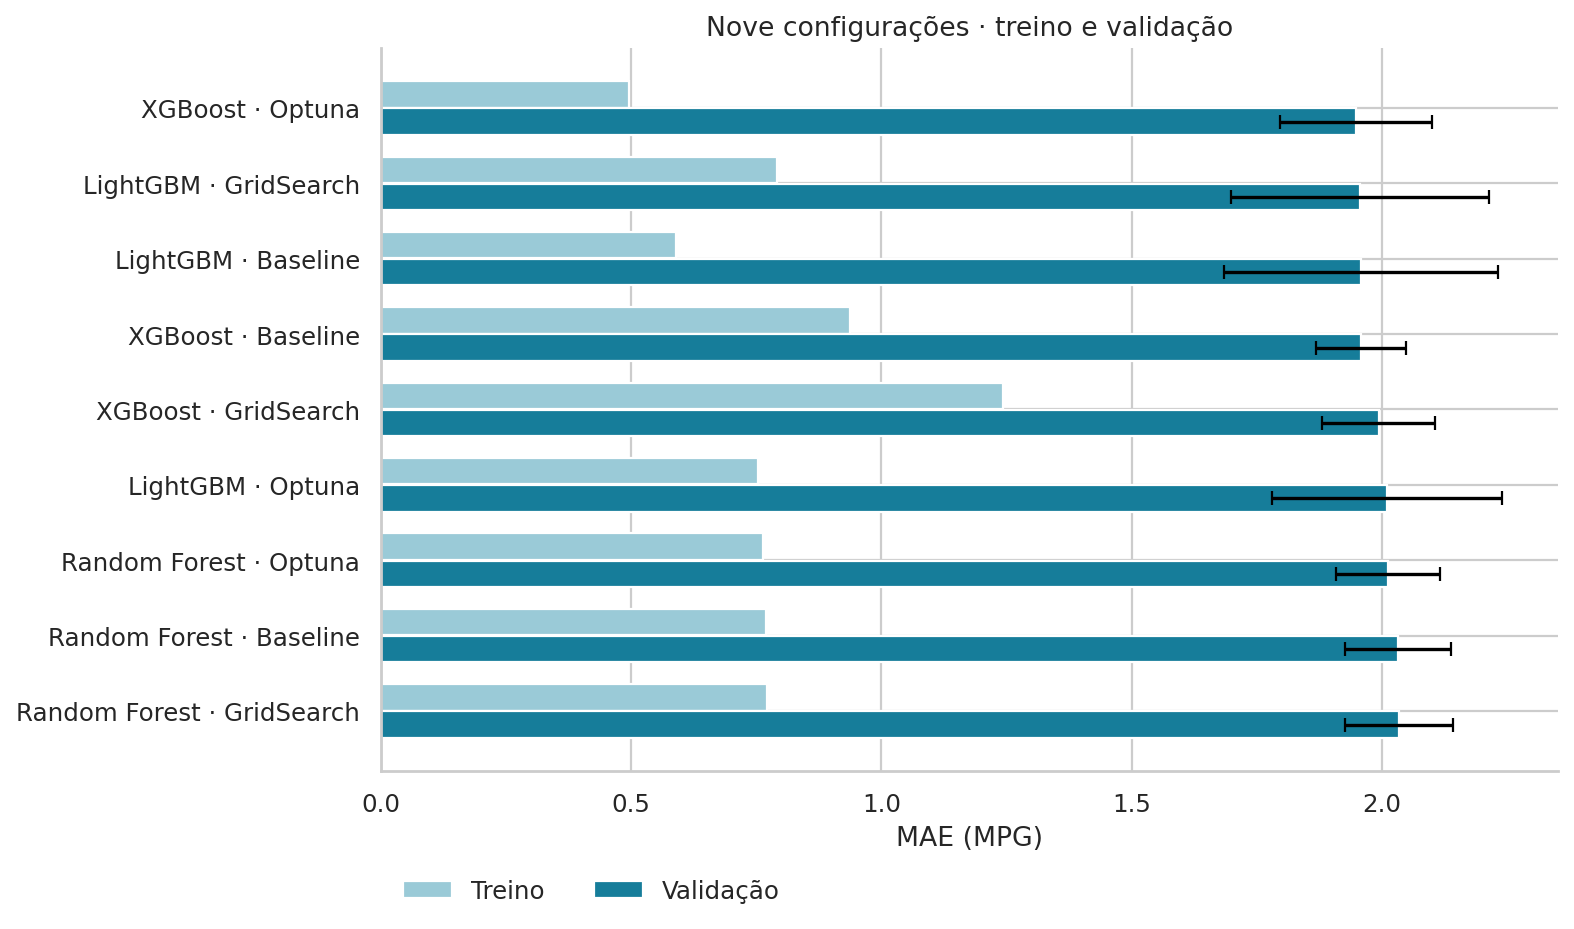

,n_treino,mae_treino,mae_cv,dp_cv
0,50,0.0781,2.6419,0.3152
1,101,0.1849,2.3949,0.1813
2,152,0.3042,2.2142,0.2329
3,203,0.4084,2.1305,0.1786
4,254,0.5004,1.9217,0.1442


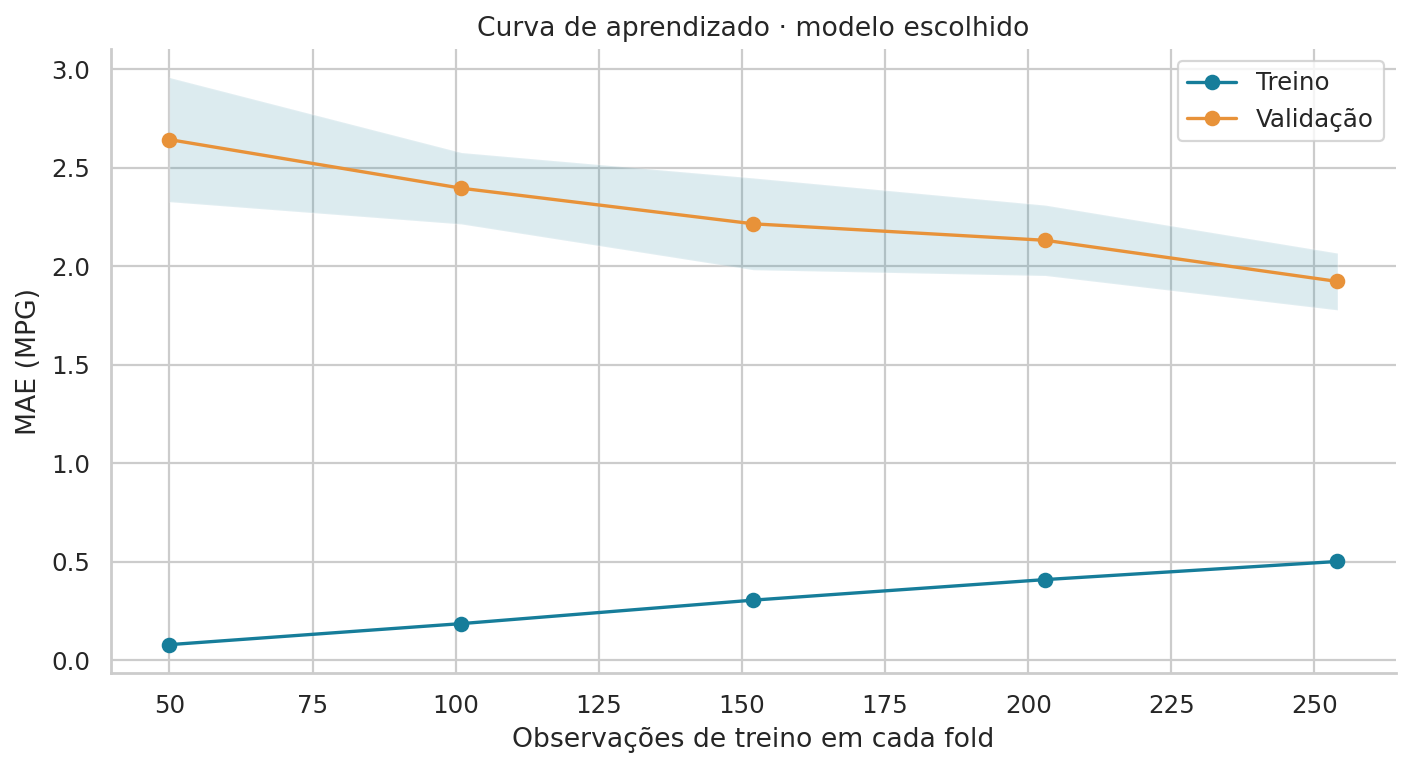

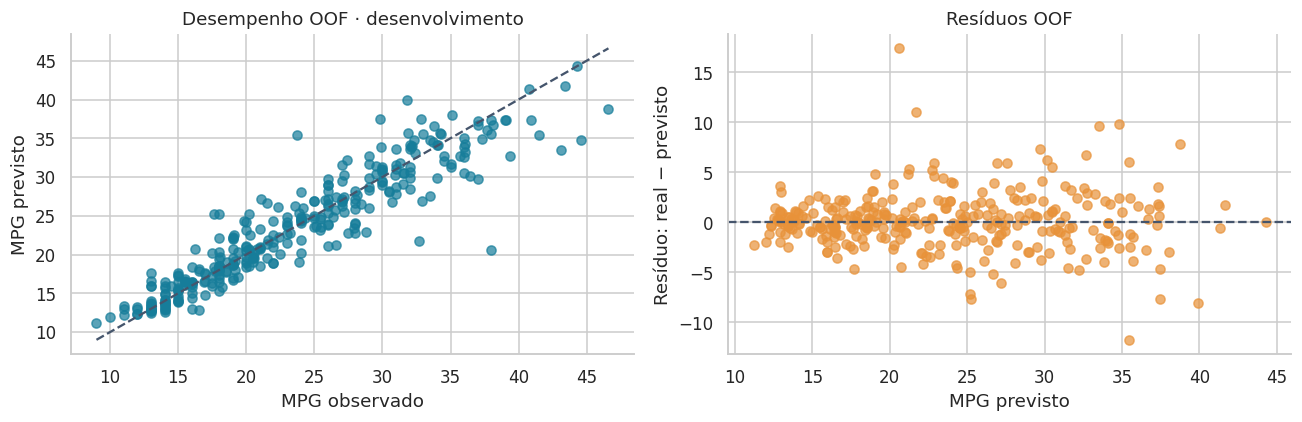

,variavel,aumento_mae,dp
5,model_year,1.9419,0.3600
3,weight,1.5333,0.2920
1,displacement,1.0313,0.4676
2,horsepower,0.9948,0.3281
0,cylinders,0.2612,0.3081
4,acceleration,0.2185,0.0878
6,origin,0.0528,0.0614


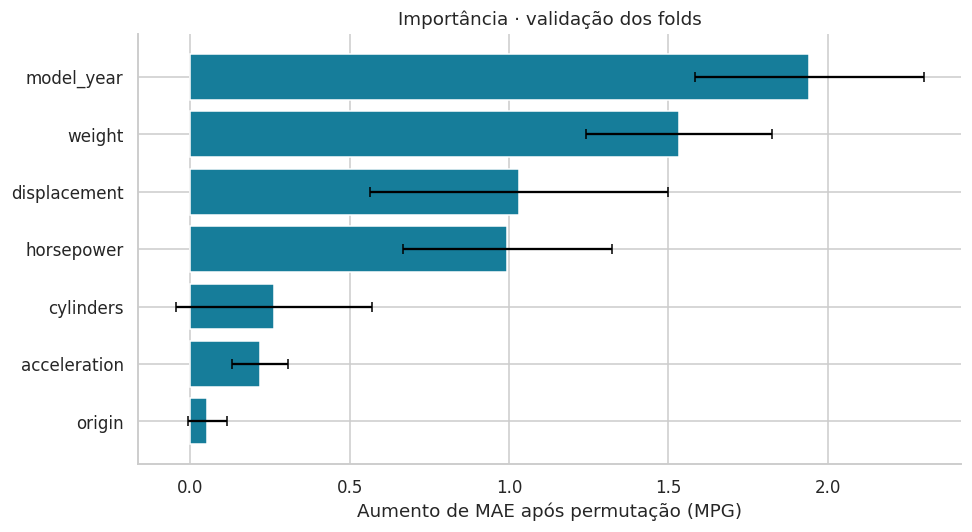

**Escolha:** XGBoost / Optuna, MAE CV
**1.948 ± 0.152 MPG**, menor valor médio observado.
A diferença para o segundo colocado é 0.008 MPG;
esse ranking não implica diferença estatisticamente comprovada.

**Generalização em desenvolvimento:** MAE de treino 0.495,
gap 1.453 MPG. A curva passa de 2.642 MPG
com 50 registros para 1.922 MPG
com 254 registros por fold.
Um erro de treino inferior ao de validação sinaliza ajuste mais forte à amostra conhecida;
não basta, isoladamente, para descartar o modelo. A comparação com a referência constante
(6.702 MPG), a curva e a dispersão contextualizam esse gap.

**Interpretação:** a maior importância média por permutação é de **model_year**.
O resíduo OOF médio é 0.115 MPG;
resíduos positivos indicam que o modelo subestimou a eficiência.
Os gráficos permitem localizar erros maiores e padrões sistemáticos. A confirmação em dados
reservados acontece somente a seguir, sem alterar a configuração escolhida.

**Conclusão sobre ajuste.** Há evidência de sobreajuste: o MAE de treino é bem menor que o de
validação e esse gap permanece no maior tamanho da curva. O erro de validação, porém, diminui
com mais registros e fica muito abaixo do preditor constante. Não há o padrão típico de
underfitting, em que treino e validação apresentam erros elevados e próximos. Mais dados e
regularização são possibilidades para um trabalho futuro; não serão testadas usando o teste reservado.

**Custo, complexidade e ganho.** A vantagem do vencedor sobre LightGBM/Grid Search é menor
que a dispersão entre folds. XGBoost/Optuna também tem gap maior que XGBoost/Grid Search.
A configuração escolhida segue a regra de menor MAE previamente definida, mas não é uma
vitória incontestável. Para uma decisão de produção, os modelos mais simples e rápidos seriam
alternativas plausíveis. O tuning trouxe ganho pequeno e, no LightGBM, Optuna não superou
nem a grade nem o baseline: aumentar a busca não garante melhorar o resultado.

In [7]:
tabela_final = pd.DataFrame(linhas).sort_values(
    ['mae_cv','dp_mae_cv','tempo_ajuste_fold_s']).reset_index(drop=True)
assert len(tabela_final)==9
display(tabela_final.round(4))
tabela_final.to_csv(BASE/'results'/'comparacao_9_modelos.csv',index=False)
vencedor = tabela_final.iloc[0]
chave = (vencedor.modelo,vencedor.estrategia)
escolhido = clone(configuracoes[chave])
print('Configuração selecionada SEM consultar teste:',chave)
display(pd.Series(escolhido.named_steps['modelo'].get_params()).to_frame('parâmetro'))

rotulos = tabela_final.modelo + ' · ' + tabela_final.estrategia
fig,ax = plt.subplots(figsize=(10,6))
pos = np.arange(len(tabela_final))
ax.barh(pos-.18,tabela_final.mae_treino,height=.35,label='Treino',color='#9ACAD7')
ax.barh(pos+.18,tabela_final.mae_cv,height=.35,xerr=tabela_final.dp_mae_cv,
        label='Validação',color='#167D9A',capsize=3)
ax.set_yticks(pos,rotulos)
ax.invert_yaxis()
ax.set(xlabel='MAE (MPG)',title='Nove configurações · treino e validação')
ax.legend(loc='upper left', bbox_to_anchor=(0,-.12), ncol=2, frameon=False)
salvar_fig('08_comparacao_final')

tamanhos,lc_train,lc_cv = learning_curve(escolhido,X_treino,y_treino,
    train_sizes=[0.2,0.4,0.6,0.8,1.0],cv=FOLDS,scoring=SCORING['mae'],n_jobs=1,
    shuffle=True,random_state=SEED,error_score='raise')
lc = pd.DataFrame({'n_treino':tamanhos,'mae_treino':(-lc_train).mean(axis=1),
                  'mae_cv':(-lc_cv).mean(axis=1),'dp_cv':(-lc_cv).std(axis=1,ddof=1)})
display(lc.round(4))
lc.to_csv(BASE/'results'/'curva_aprendizado.csv',index=False)
fig,ax = plt.subplots()
ax.plot(lc.n_treino,lc.mae_treino,'o-',label='Treino')
ax.plot(lc.n_treino,lc.mae_cv,'o-',label='Validação')
ax.fill_between(lc.n_treino,lc.mae_cv-lc.dp_cv,lc.mae_cv+lc.dp_cv,alpha=.15)
ax.set(xlabel='Observações de treino em cada fold',ylabel='MAE (MPG)',title='Curva de aprendizado · modelo escolhido')
ax.legend()
salvar_fig('09_curva_aprendizado')

pred_oof = cross_val_predict(escolhido,X_treino,y_treino,cv=FOLDS,n_jobs=1)
fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].scatter(y_treino,pred_oof,alpha=.7,color='#167D9A')
limites=[min(y_treino.min(),pred_oof.min()),max(y_treino.max(),pred_oof.max())]
axes[0].plot(limites,limites,'--',color='#45556C')
axes[0].set(xlabel='MPG observado',ylabel='MPG previsto',title='Desempenho OOF · desenvolvimento')
axes[1].scatter(pred_oof,y_treino-pred_oof,alpha=.7,color='#E89239')
axes[1].axhline(0,color='#45556C',linestyle='--')
axes[1].set(xlabel='MPG previsto',ylabel='Resíduo: real − previsto',title='Resíduos OOF')
salvar_fig('10_desempenho_oof')

importancias = []
for a,b in FOLDS:
    modelo_fold = clone(escolhido).fit(X_treino.iloc[a],y_treino.iloc[a])
    imp = permutation_importance(modelo_fold,X_treino.iloc[b],y_treino.iloc[b],
        scoring=SCORING['mae'],n_repeats=5,random_state=SEED,n_jobs=1)
    importancias.append(imp.importances)
valores_imp = np.concatenate(importancias,axis=1)
imp_df = pd.DataFrame({'variavel':FEATURES,'aumento_mae':valores_imp.mean(axis=1),
                      'dp':valores_imp.std(axis=1,ddof=1)}).sort_values('aumento_mae',ascending=False)
display(imp_df.round(4))
imp_df.to_csv(BASE/'results'/'importancia_permutacao.csv',index=False)
fig,ax = plt.subplots()
ordem = imp_df.iloc[::-1]
ax.barh(ordem.variavel,ordem.aumento_mae,xerr=ordem.dp,capsize=3,color='#167D9A')
ax.set(xlabel='Aumento de MAE após permutação (MPG)',title='Importância · validação dos folds')
salvar_fig('11_importancia')

vice = tabela_final.iloc[1]
texto(f"""**Escolha:** {vencedor.modelo} / {vencedor.estrategia}, MAE CV
**{vencedor.mae_cv:.3f} ± {vencedor.dp_mae_cv:.3f} MPG**, menor valor médio observado.
A diferença para o segundo colocado é {vice.mae_cv-vencedor.mae_cv:.3f} MPG;
esse ranking não implica diferença estatisticamente comprovada.

**Generalização em desenvolvimento:** MAE de treino {vencedor.mae_treino:.3f},
gap {vencedor.gap_mae:.3f} MPG. A curva passa de {lc.mae_cv.iloc[0]:.3f} MPG
com {int(lc.n_treino.iloc[0])} registros para {lc.mae_cv.iloc[-1]:.3f} MPG
com {int(lc.n_treino.iloc[-1])} registros por fold.
Um erro de treino inferior ao de validação sinaliza ajuste mais forte à amostra conhecida;
não basta, isoladamente, para descartar o modelo. A comparação com a referência constante
({cv_constante.mean():.3f} MPG), a curva e a dispersão contextualizam esse gap.

**Interpretação:** a maior importância média por permutação é de **{imp_df.iloc[0].variavel}**.
O resíduo OOF médio é {np.mean(y_treino-pred_oof):.3f} MPG;
resíduos positivos indicam que o modelo subestimou a eficiência.
Os gráficos permitem localizar erros maiores e padrões sistemáticos. A confirmação em dados
reservados acontece somente a seguir, sem alterar a configuração escolhida.""")

texto('**Conclusão sobre ajuste.** Há evidência de sobreajuste: o MAE de treino é bem menor que o de\nvalidação e esse gap permanece no maior tamanho da curva. O erro de validação, porém, diminui\ncom mais registros e fica muito abaixo do preditor constante. Não há o padrão típico de\nunderfitting, em que treino e validação apresentam erros elevados e próximos. Mais dados e\nregularização são possibilidades para um trabalho futuro; não serão testadas usando o teste reservado.\n\n**Custo, complexidade e ganho.** A vantagem do vencedor sobre LightGBM/Grid Search é menor\nque a dispersão entre folds. XGBoost/Optuna também tem gap maior que XGBoost/Grid Search.\nA configuração escolhida segue a regra de menor MAE previamente definida, mas não é uma\nvitória incontestável. Para uma decisão de produção, os modelos mais simples e rápidos seriam\nalternativas plausíveis. O tuning trouxe ganho pequeno e, no LightGBM, Optuna não superou\nnem a grade nem o baseline: aumentar a busca não garante melhorar o resultado.')


<br>

---

<br>

### **Exercício 7 — Teste final, consistência do modelo, entrega em produção e apresentação — 1,5 ponto**

Somente agora utilize $\mathcal{D}_{\mathrm{teste}}$. Refaça o treinamento da configuração selecionada usando todo $\mathcal{D}_{\mathrm{treino}}$ e execute a avaliação final uma única vez no conjunto de teste.

1. **Avaliação final — 0,50 ponto.** Calcule a métrica principal e as métricas auxiliares em $\mathcal{D}_{\mathrm{teste}}$. Compare o resultado de teste com a validação cruzada. Discuta se o desempenho final é compatível com o que era esperado durante o desenvolvimento.
2. **Teste de consistência — 0,40 ponto.** Selecione pelo menos cinco observações que não participaram do treinamento. Para cada uma, apresente as principais entradas, o valor real $y$, a previsão $\hat{y}$ e:
   - em classificação, a probabilidade prevista quando o estimador oferecer `predict_proba`;
   - em regressão, o erro individual $e_i=y_i-\hat{y}_i$.

   Interprete os casos e verifique se o comportamento do modelo é coerente com o padrão aprendido. Inclua pelo menos um caso em que o modelo acerta bem e um caso mais difícil, quando isso existir nos dados.
3. **GitHub e Streamlit — 0,60 ponto.** Disponibilize o projeto em um repositório GitHub e construa uma aplicação Streamlit que utilize **a mesma preparação de dados e o mesmo modelo final**. A interface deve receber as variáveis necessárias, gerar a previsão e apresentar o resultado de forma legível. O repositório deve conter, no mínimo:
   - `README.md` com descrição do problema, instruções de instalação e execução, links e resumo dos resultados;
   - notebook do CheckPoint05;
   - código da aplicação Streamlit;
   - arquivo de dependências (`requirements.txt` ou equivalente);
   - artefato do pipeline/modelo final ou código reproduzível para gerá-lo;
   - instruções para obtenção da base, caso ela não possa ser versionada no repositório.

Registre abaixo os links finais:

- **GitHub:** inserir URL do repositório.
- **Streamlit:** inserir URL da aplicação.

4. **Apresentação da solução — requisito obrigatório.** O grupo deverá realizar uma apresentação oral de **no máximo 10 minutos**. A exposição deve ser objetiva e demonstrar domínio sobre o desenvolvimento realizado. Organize a apresentação para contemplar, no mínimo:
   - problema escolhido, contexto, base de dados e variável-alvo;
   - principais decisões de data wrangling e escolha das variáveis;
   - comparação entre Random Forest, XGBoost e LightGBM;
   - resultados do Grid Search e do Optuna e justificativa da configuração final;
   - análise de overfitting e underfitting;
   - desempenho no conjunto de teste e principais conclusões sobre generalização;
   - demonstração breve da aplicação Streamlit e do teste de paridade entre notebook e interface.

A apresentação poderá utilizar slides ou a demonstração direta do projeto, desde que o tempo máximo seja respeitado. Todos os integrantes devem estar preparados para responder a perguntas sobre a solução desenvolvida.

<div style="border-left: 4px solid #666; padding: 10px 16px; margin: 18px 0;">
<strong>Teste adicional de paridade:</strong> escolha pelo menos uma das observações do teste de consistência, reproduza os mesmos valores de entrada na aplicação Streamlit e verifique se a previsão exibida pela interface coincide com a previsão produzida pelo pipeline no notebook. Divergências devem ser investigadas antes da entrega.
</div>

### Resposta · Teste final e artefato único
Agora ajustamos a configuração escolhida em todo o treino e abrimos o conjunto reservado.
As métricas são calculadas a partir de **uma única geração de previsões de teste**.
Após isso, nenhuma configuração é escolhida ou ajustada com base nesses resultados.

O teste de consistência utiliza cinco registros do teste, incluindo os de menor e maior erro
absoluto (selecionados apenas para ilustrar o comportamento, depois da avaliação).
O pipeline salvo contém imputação, codificação e regressor; o aplicativo carrega esse mesmo arquivo.
A verificação por `AppTest` do Streamlit, distribuída em `verificar_paridade.py`, reproduz as entradas
dos cinco casos na interface e compara sua saída com as previsões registradas no notebook.


Paridade notebook → artefato recarregado: OK nos 5 casos.
GitHub: PENDENTE DE PUBLICAÇÃO
Streamlit: PENDENTE DE PUBLICAÇÃO


,validacao_cruzada,teste
MAE (MPG),1.9482,1.7419
RMSE (MPG),2.8655,2.3784
R²,0.8649,0.8948


,car_name,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,real_mpg,previsto_mpg,erro_real_menos_previsto,erro_absoluto
261,amc concord d/l,6,258.0,120.0,3410.0,15.1,78,1,18.1,18.105000,-0.0050,0.0050
104,ford country,8,400.0,167.0,4906.0,12.5,73,1,12.0,12.598500,-0.5985,0.5985
55,volkswagen model 111,4,97.0,60.0,1834.0,19.0,71,2,27.0,28.354200,-1.3542,1.3542
396,ford ranger,4,120.0,79.0,2625.0,18.6,82,1,28.0,30.382299,-2.3823,2.3823
394,vw pickup,4,97.0,52.0,2130.0,24.6,82,2,44.0,36.025799,7.9742,7.9742


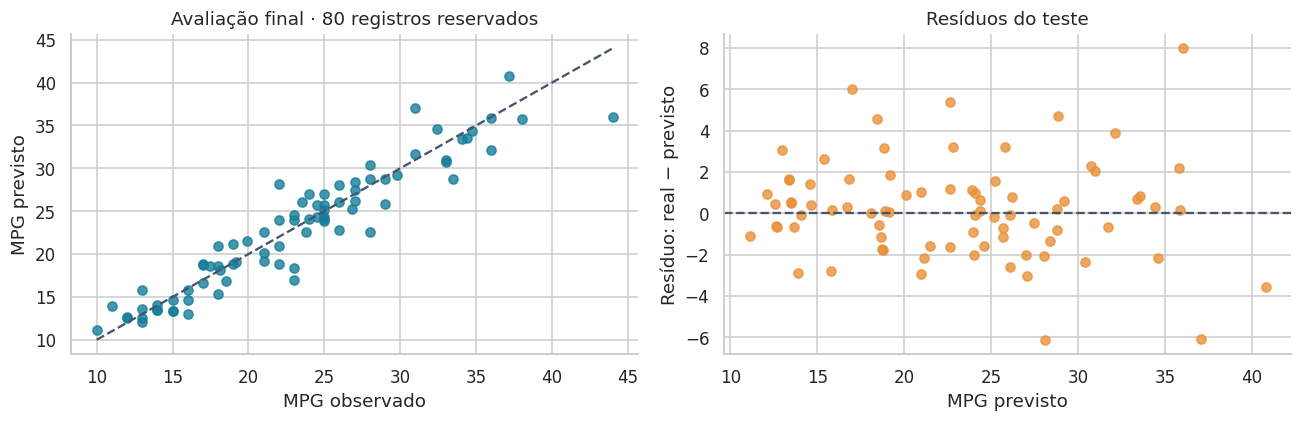

**Resultado final:** MAE **1.742 MPG**, RMSE
**2.378 MPG**, R² **0.895**.
O MAE de teste ficou -0.206 MPG em relação à média da CV.
Essa comparação considera uma única partição de 80 registros: não demonstra precisão garantida
nem permite concluir equivalência estatística apenas pela proximidade das médias.

**Consistência:** no caso de menor erro, amc concord d/l, o valor real é 18.10 MPG
e a previsão 18.11 MPG (erro absoluto 0.005).
No caso mais difícil, vw pickup, o real é 44.00 MPG
e a previsão 36.03 MPG (erro absoluto 7.974).
O caso difícil evidencia que a média de erro não descreve todas as previsões individuais.

**Limitações:** amostra pequena e histórica, atributos correlacionados, fatores de consumo não observados
(condução, manutenção e condições de uso), seleção em CV não aninhada e uma única separação de teste.
Não extrapolamos para carros modernos, outros combustíveis ou uso rodoviário.
MPG foi mantido como alvo; o aplicativo apenas converte a saída para km/L usando 0,425143707.

**Reprodução:** execute `python verificar_paridade.py` após o notebook para verificar a interface.
Consulte `ROTEIRO_APRESENTACAO.md` para a exposição de até dez minutos.


**Conclusão do teste.** O erro reservado ficou na mesma ordem de grandeza da validação e
ligeiramente menor nesta partição. Isso é compatível com a generalização observada no desenvolvimento,
apesar do sobreajuste ao treino. O caso de maior erro mostra uma limitação concreta: o modelo
subestimou a eficiência de um veículo muito econômico. A média de erro não é garantia individual.

In [8]:
X_teste = dados.loc[idx_teste,FEATURES].copy()
y_teste = dados.loc[idx_teste,'mpg'].copy()
modelo_final = clone(escolhido).fit(X_treino,y_treino)
pred_teste = modelo_final.predict(X_teste)
METRICAS_TESTE = {'mae':float(mean_absolute_error(y_teste,pred_teste)),
    'rmse':float(np.sqrt(mean_squared_error(y_teste,pred_teste))),
    'r2':float(r2_score(y_teste,pred_teste))}
display(pd.DataFrame({'validacao_cruzada':[vencedor.mae_cv,vencedor.rmse_cv,vencedor.r2_cv],
                     'teste':[METRICAS_TESTE['mae'],METRICAS_TESTE['rmse'],METRICAS_TESTE['r2']]},
                     index=['MAE (MPG)','RMSE (MPG)','R²']).round(4))
avaliacao = X_teste.copy()
avaliacao.insert(0,'car_name',dados.loc[idx_teste,'car_name'])
avaliacao['real_mpg'] = y_teste
avaliacao['previsto_mpg'] = pred_teste
avaliacao['erro_real_menos_previsto'] = y_teste-pred_teste
avaliacao['erro_absoluto'] = abs(y_teste-pred_teste)
avaliacao.to_csv(BASE/'results'/'previsoes_teste.csv',index_label='id_linha')
ordenada = avaliacao.sort_values('erro_absoluto')
consistencia = ordenada.iloc[[0,len(ordenada)//4,len(ordenada)//2,3*len(ordenada)//4,len(ordenada)-1]].copy()
display(consistencia.round(4))
consistencia.to_csv(BASE/'results'/'consistencia_5_casos.csv',index_label='id_linha')

joblib.dump(modelo_final,BASE/'artifacts'/'pipeline.joblib',compress=3)
carregado = joblib.load(BASE/'artifacts'/'pipeline.joblib')
pred_recarregada = carregado.predict(consistencia[FEATURES])
assert np.allclose(pred_recarregada,consistencia.previsto_mpg,rtol=0,atol=1e-9)
print('Paridade notebook → artefato recarregado: OK nos 5 casos.')

def json_limpo(obj):
    return json.loads(pd.DataFrame(obj).to_json(orient='records'))
casos = json_limpo(consistencia.reset_index(names='id_linha'))
metadados = {
    'modelo':vencedor.modelo,'estrategia':vencedor.estrategia,'seed':SEED,
    'features':FEATURES,'mae_cv':float(vencedor.mae_cv),'dp_mae_cv':float(vencedor.dp_mae_cv),
    'mae_treino':float(vencedor.mae_treino),'metricas_teste':METRICAS_TESTE,
    'n_treino':len(X_treino),'n_teste':len(X_teste),'n_trials_por_modelo':N_TRIALS,
    'sha256_dados':SHA256_DADOS,'versoes':VERSOES,
    'parametros_modelo':modelo_final.named_steps['modelo'].get_params(),
    'limites_treino':{c:{'min':float(X_treino[c].min()),'max':float(X_treino[c].max())} for c in NUM},
    'casos_consistencia':casos,
}
(BASE/'artifacts'/'metadata.json').write_text(json.dumps(metadados,indent=2,ensure_ascii=False,default=str))

fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].scatter(y_teste,pred_teste,color='#167D9A',alpha=.8)
limites=[min(y_teste.min(),pred_teste.min()),max(y_teste.max(),pred_teste.max())]
axes[0].plot(limites,limites,'--',color='#45556C')
axes[0].set(xlabel='MPG observado',ylabel='MPG previsto',title='Avaliação final · 80 registros reservados')
axes[1].scatter(pred_teste,y_teste-pred_teste,color='#E89239',alpha=.8)
axes[1].axhline(0,color='#45556C',linestyle='--')
axes[1].set(xlabel='MPG previsto',ylabel='Resíduo: real − previsto',title='Resíduos do teste')
salvar_fig('12_teste_final')

delta_teste = METRICAS_TESTE['mae']-vencedor.mae_cv
bom, dificil = consistencia.iloc[0],consistencia.iloc[-1]
texto(f"""**Resultado final:** MAE **{METRICAS_TESTE['mae']:.3f} MPG**, RMSE
**{METRICAS_TESTE['rmse']:.3f} MPG**, R² **{METRICAS_TESTE['r2']:.3f}**.
O MAE de teste ficou {delta_teste:+.3f} MPG em relação à média da CV.
Essa comparação considera uma única partição de 80 registros: não demonstra precisão garantida
nem permite concluir equivalência estatística apenas pela proximidade das médias.

**Consistência:** no caso de menor erro, {bom.car_name}, o valor real é {bom.real_mpg:.2f} MPG
e a previsão {bom.previsto_mpg:.2f} MPG (erro absoluto {bom.erro_absoluto:.3f}).
No caso mais difícil, {dificil.car_name}, o real é {dificil.real_mpg:.2f} MPG
e a previsão {dificil.previsto_mpg:.2f} MPG (erro absoluto {dificil.erro_absoluto:.3f}).
O caso difícil evidencia que a média de erro não descreve todas as previsões individuais.

**Limitações:** amostra pequena e histórica, atributos correlacionados, fatores de consumo não observados
(condução, manutenção e condições de uso), seleção em CV não aninhada e uma única separação de teste.
Não extrapolamos para carros modernos, outros combustíveis ou uso rodoviário.
MPG foi mantido como alvo; o aplicativo apenas converte a saída para km/L usando 0,425143707.

**Reprodução:** execute `python verificar_paridade.py` após o notebook para verificar a interface.
Consulte `ROTEIRO_APRESENTACAO.md` para a exposição de até dez minutos.
""")

# Preencher após publicação real. Não substitua por links fictícios.
URL_GITHUB = ''
URL_STREAMLIT = ''
print('GitHub:',URL_GITHUB or 'PENDENTE DE PUBLICAÇÃO')
print('Streamlit:',URL_STREAMLIT or 'PENDENTE DE PUBLICAÇÃO')

texto('**Conclusão do teste.** O erro reservado ficou na mesma ordem de grandeza da validação e\nligeiramente menor nesta partição. Isso é compatível com a generalização observada no desenvolvimento,\napesar do sobreajuste ao treino. O caso de maior erro mostra uma limitação concreta: o modelo\nsubestimou a eficiência de um veículo muito econômico. A média de erro não é garantia individual.')


## Referências e checklist de entrega
- Quinlan, R. (1993). Auto MPG. UCI. https://doi.org/10.24432/C5859H — base e atribuição CC BY 4.0.
- Scikit-learn: https://scikit-learn.org/stable/modules/cross_validation.html
- XGBoost: https://xgboost.readthedocs.io/en/stable/python/python_api.html
- LightGBM: https://lightgbm.readthedocs.io/en/stable/pythonapi/lightgbm.LGBMRegressor.html
- Optuna: https://optuna.readthedocs.io/en/stable/reference/generated/optuna.study.Study.html
- Streamlit: https://docs.streamlit.io/deploy/streamlit-community-cloud/deploy-your-app

Antes de entregar: preencher todos os nomes e RMs; publicar o repositório e o Streamlit;
inserir seus links no Exercício 7 e no README; conferir Run All; ensaiar a apresentação.


## Verificação realizada da interface Streamlit

Os cinco casos foram inseridos pelos widgets da interface usando o AppTest do Streamlit.
Todas as previsões coincidiram com o notebook dentro da tolerância de 1e-8 MPG; o valor exibido também foi conferido.

| Caso | Notebook (MPG) | Interface (MPG) | Resultado |
| --- | ---: | ---: | --- |
| 1 | 18.105032 | 18.105032 | OK |
| 2 | 12.598528 | 12.598528 | OK |
| 3 | 28.354172 | 28.354172 | OK |
| 4 | 30.382254 | 30.382254 | OK |
| 5 | 36.025837 | 36.025837 | OK |

Relatório: `results/paridade_streamlit.json`. Após qualquer novo treinamento, execute novamente `python verificar_paridade.py`. Esta validação é local e não substitui a conferência do link após a publicação.